,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


--- RESULTADOS DE LOS MODELOS DE ENSAMBLE ---

1. Random Forest Accuracy: 0.9750
2. Gradient Boosting Accuracy: 1.0000
3. AdaBoost Accuracy: 1.0000

Reporte detallado del mejor modelo (Random Forest):
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         4
       drugB       1.00      1.00      1.00         2
       drugC       1.00      0.75      0.86         4
       drugX       0.93      1.00      0.96        13
       drugY       1.00      1.00      1.00        17

    accuracy                           0.97        40
   macro avg       0.99      0.95      0.96        40
weighted avg       0.98      0.97      0.97        40

Gráfica 'importancia_variables_drogas.png' exportada con éxito en HD.


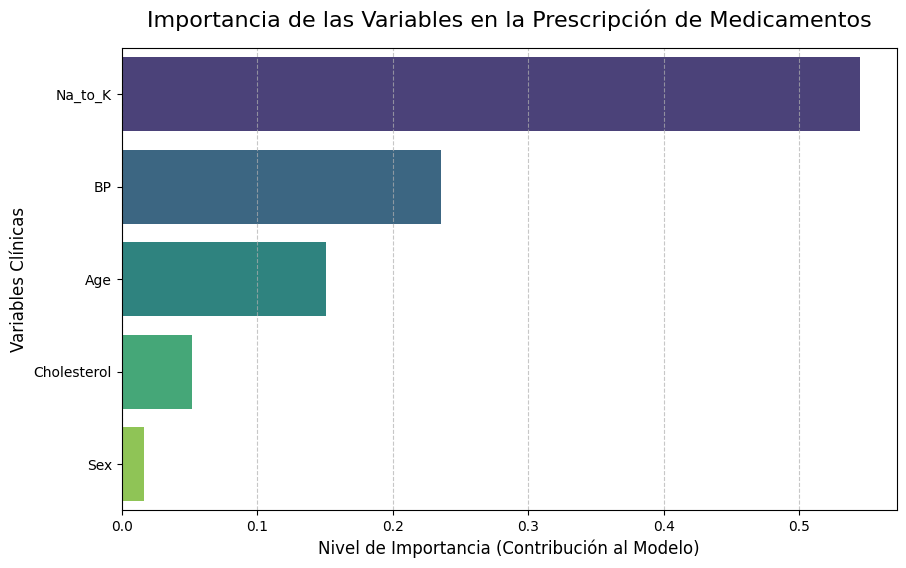

In [1]:
# Módulo: Ensambles, Consenso y Potenciación
# Proyecto: Predicción de Tratamiento Médico (Drug Classification)
# Alumno: Yamil Salomón

# 1. Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os # <-- Nueva librería para manejar rutas

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

import warnings
warnings.filterwarnings("ignore")

# 2. Carga de datos con Ruta Absoluta
# Cambiamos el directorio de trabajo a tu carpeta exacta de EBAC
ruta_ebac = r"C:\Users\Yamil\OneDrive\Escritorio\Escritorio\Yamil\EBAC (CIENCIA DE DATOS)\Bloque 4 Aprendizaje de máquina supervisado\MOD 6 Ensambles Consenso y Potenciación"
os.chdir(ruta_ebac)

# Ahora Pandas buscará 'drugs.csv' directamente en esa carpeta
df = pd.read_csv('drugs.csv')

# Para confirmar que cargó bien, mostramos los primeros 5 registros
display(df.head())

# 3. Preprocesamiento de Datos
# Convertimos las variables categóricas a numéricas para que los modelos puedan procesarlas
le_sex = LabelEncoder()
le_bp = LabelEncoder()
le_chol = LabelEncoder()
le_drug = LabelEncoder()

df['Sex'] = le_sex.fit_transform(df['Sex'])
df['BP'] = le_bp.fit_transform(df['BP'])
df['Cholesterol'] = le_chol.fit_transform(df['Cholesterol'])
df['Drug_Encoded'] = le_drug.fit_transform(df['Drug'])

# Definición de variables predictoras (X) y variable a pronosticar (y)
feature_cols = ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']
X = df[feature_cols]
y = df['Drug_Encoded']

# División en datos de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# 4. Entrenamiento y Evaluación de Modelos de Ensamble

print("--- RESULTADOS DE LOS MODELOS DE ENSAMBLE ---\n")

# A. Bosques Aleatorios (Random Forest - Consenso)
rf = RandomForestClassifier(n_estimators=100, random_state=1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"1. Random Forest Accuracy: {acc_rf:.4f}")

# B. Gradient Boosting Trees (Potenciación)
gbt = GradientBoostingClassifier(n_estimators=100, random_state=1, max_depth=3)
gbt.fit(X_train, y_train)
y_pred_gbt = gbt.predict(X_test)
acc_gbt = accuracy_score(y_test, y_pred_gbt)
print(f"2. Gradient Boosting Accuracy: {acc_gbt:.4f}")

# C. AdaBoost (Potenciación con Árboles de Decisión como base)
dt_base = DecisionTreeClassifier(max_depth=2, random_state=1)
abc = AdaBoostClassifier(estimator=dt_base, n_estimators=50, learning_rate=1, random_state=1)
abc.fit(X_train, y_train)
y_pred_abc = abc.predict(X_test)
acc_abc = accuracy_score(y_test, y_pred_abc)
print(f"3. AdaBoost Accuracy: {acc_abc:.4f}\n")

print("Reporte detallado del mejor modelo (Random Forest):")
# Invertimos la transformación para ver los nombres reales de las drogas en el reporte
print(classification_report(y_test, y_pred_rf, target_names=le_drug.classes_))

# 5. Visualización: Importancia de las Variables (HD)

# Obtenemos la importancia de las características del Random Forest
importances = rf.feature_importances_

# Ordenamos de mayor a menor
indices = np.argsort(importances)[::-1]
nombres_variables = [feature_cols[i] for i in indices]
valores_importancia = importances[indices]

# Configuración de la gráfica
plt.figure(figsize=(10, 6))
sns.barplot(x=valores_importancia, y=nombres_variables, palette='viridis')
plt.title('Importancia de las Variables en la Prescripción de Medicamentos', fontsize=16, pad=15)
plt.xlabel('Nivel de Importancia (Contribución al Modelo)', fontsize=12)
plt.ylabel('Variables Clínicas', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Exportación en Alta Calidad (HD)
plt.savefig('importancia_variables_drogas.png', dpi=300, facecolor='white', bbox_inches='tight')
print("Gráfica 'importancia_variables_drogas.png' exportada con éxito en HD.")
plt.show()